In [21]:
import numpy as np
from matplotlib import pyplot as plt
path = 'C:/Users/alexv/Desktop/Università/astrostat/astrostatistics_bicocca_2025/solutions/transient.npy'
from sklearn.mixture import GaussianMixture
from astroML.resample import jackknife
from astroML.stats import sigmaG
from scipy.stats import chi2
import scipy
#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize = 10, usetex = True)
from scipy.stats import loguniform
from sklearn import datasets
from sklearn import manifold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


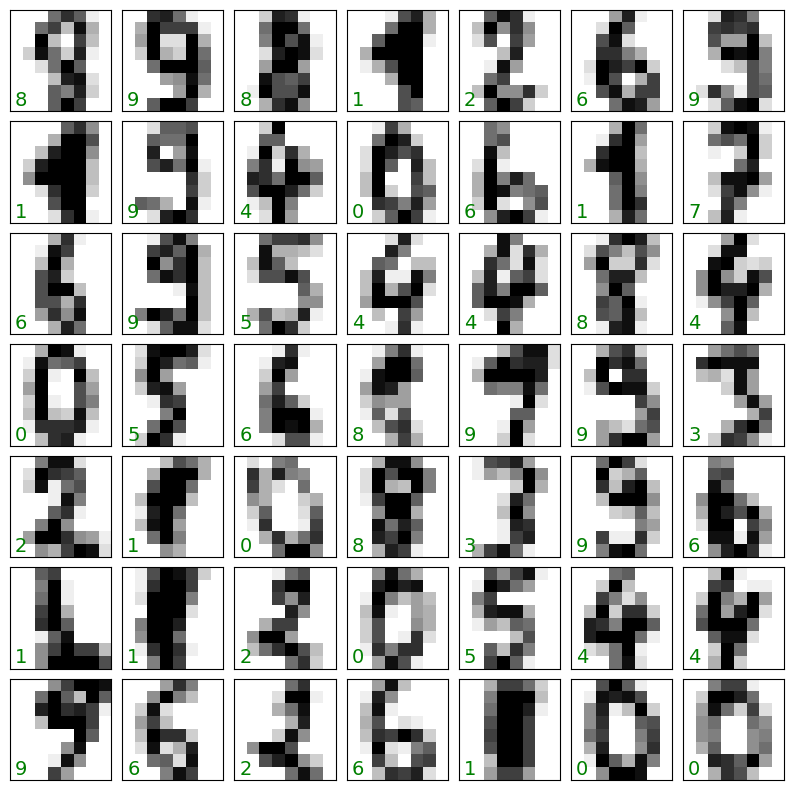

In [14]:
digits = datasets.load_digits()
print(digits.images.shape)
print(digits.keys())
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(4321)
mychoices = np.random.choice(digits.images.shape[0],100)
np.random.seed()
for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    

In [15]:
isomap = manifold.Isomap(n_neighbors = 6, n_components = 2) 
#transform the dataset 

digits_transf = isomap.fit_transform(digits.data)
print(digits_transf.shape)
y = digits.target #per le label

C:\Users\alexv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\alexv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 2)


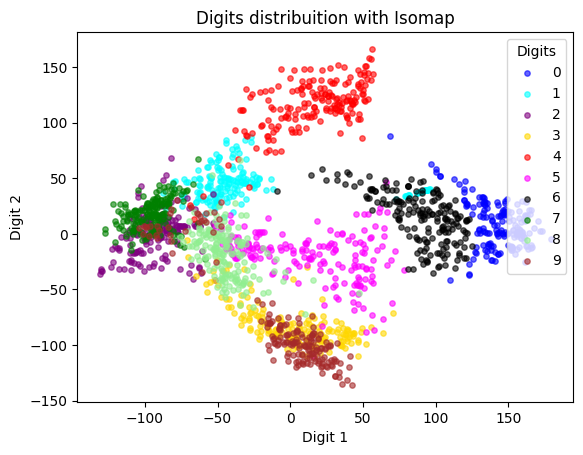

In [16]:
colors = ['blue', 'cyan', 'purple', 'gold', 'red', 'magenta', 'black', 'green', 'lightgreen','brown']
labels = ['0','1','2','3','4','5','6','7','8','9']
for i in range(10):
    idx = y == i
    plt.scatter(digits_transf[idx,0], digits_transf[idx,1], color = colors[i], label = str(i), alpha = 0.6, s = 15)
plt.legend(title = 'Digits')
plt.title('Digits distribuition with Isomap')
plt.xlabel('Digit 1')
plt.ylabel('Digit 2')
plt.show()

In [32]:
model = LogisticRegression(solver = 'sag', max_iter = 2000)
X = digits.data
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,test_size=0.8, random_state = 2)
model.fit(Xtrain, ytrain)


LogisticRegression(max_iter=2000, solver='sag')

In [33]:
predict = model.predict(Xtest)
#accuracy 
acc_sup_test = accuracy_score(ytest, predict)
#acc_sup_train = accuracy_score(ytrain,predict)
print(f' Accuracy test on test sample: {acc_sup_test}')

 Accuracy test on test sample: 0.9457579972183588


In [34]:
from sklearn.metrics import confusion_matrix
#y = digits.target
matrix = confusion_matrix(ytest, predict)
print(f'test: {matrix}')


test: [[141   0   0   0   2   0   0   0   0   0]
 [  0 138   0   0   2   0   5   0   2   1]
 [  0   5 138   0   0   0   0   0   0   0]
 [  0   0   1 133   0   5   0   4   5   0]
 [  0   0   0   0 138   0   0   0   1   3]
 [  0   0   0   0   1 141   1   0   0   7]
 [  0   1   0   0   2   0 145   0   0   0]
 [  0   0   0   0   1   0   0 142   1   2]
 [  0   4   0   2   2   7   0   0 117   2]
 [  0   1   0   1   0   2   0   1   4 127]]


C:\Users\alexv\AppData\Local\Temp\ipykernel_6128\4186888209.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(matrix), cmap = 'Blues')


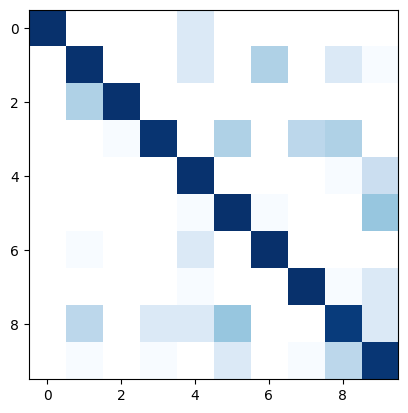

In [42]:
plt.imshow(np.log(matrix), cmap = 'Blues')